# KIN 482D: Computational modeling of human sensorimotor control and learning

## Marginalization and Chapter 13: Combining inference with utility&mdash;i.e., Bayesian Decision Theory

# Announcements

- **Change in due dates for final project**
    - Final project notebook now due on Tues, 3/31
    - Peer review feedback now due on Mon, 4/6
    - My bias was towards providing you more time to work on project
- Quiz on HMMs/KFs/marginalization on Wed
- We are starting on Ch. 13 early this week due to its link to topic of marginalization
- This week and next we will go back-and-forth between new topics (marginalization, Statistical Decision Theory) and older ones (HMMs, KFs, etc.)
    - Goal is to tie new techniques to strong intuitions/applications
    - Bring your attention to connections between all topics/methods learned throughout semester

<center><img src="images/figI-trommershauser-et-al.png" width=850></center>

- Sketch out actual task
- Other examples?
- [Trommershauser & Landy (2008)](https://canvas.ubc.ca/courses/177413/files/folder/articles?preview=43535725) provides a great intuitive overview of Statistical Decision Theory

## How can we make optimal decisions when potential rewards and costs are involved? 

- Up until now, we were mainly dealing with "pure" perceptual tasks
- We assumed the ideal observer is either trying to maximize accuracy (discrete tasks) or minimize MSE (continuous tasks), which are reasonable assumptions
- We now consider decisions that are tied to actions and that have different consequences

<center><img src="images/kording-and-wolpert-2006-box-1.png" width=700></center>

<center>From Kording & Wolpert (2006)</center>

## Decision Theory: What type of function?

- Don't be confused by all the different terminology you will see. They all refer to essentially the same thing (you can either replace one term for another or flip the sign to switch out terms)
    - Cost function
    - Loss function
    - J
    - Utility function (opposite sign as previous three)
    - Reward function (similar to utility)
- Depending on whether we are counting up "losses" or "gains", the ideal observer wants to minimize or maximize these quantities

## Simple real world example

<img src="images/fig13-1.png">

$$EC(a) = \sum_s C(a, s)p(s)$$

<center><b>Work out expected costs of each action.</b></center>

## Statistical Decision Theory 

What is the best movement plan? Agent must take into account potential rewards and costs in deciding? Agent should also take into account the uncertain mapping from movement plan (selected action) to outcome (actual reach trajectory). 

&nbsp;

<center><img src="images/figI-trommershauser-et-al.png" width=850></center>

<center><img src="images/figII-trommershauser-et-al.png" width=750></center>

<center><b>From Trommershauser et al (2008)</b></center>

## How to test optimal movement planning in the lab? 

<center><img src="images/fig1-trommershauser-et-al.png"></center>

## Let's talk marginalization (chapter 8.3)

In simplest terms, marginalization is the technique of converting a probability distribution over multiple variables into a probability over one variable. "The combination of Bayes' rule and *marginalization* powers virtually all of Bayesian modeling."

We first encountered marginalization in the first few weeks when going over how to compute the denominator of Bayes' rule. For example:

\begin{align}
p(obs) &= p(obs, H) \\
&= \sum_H p(obs|H)p(H)
\end{align}

Fun example: Probability that the sum of two die rolls equals X. **[Board.]**

### Marginalization (from Appendix B)

- *Marginalization* refers to the procedure of obtaining from a joint distribution over multiple variables the distribution over a subset of those variables. 
- For example, if $p(x, y)$ is the joint distribution of $X$ and $Y$, then summing over $Y$ produces the distribution of $X$ alone:
$$\sum_y p(x,y) = p(x)$$
$$\text{Or, in the continuous case:}$$
$$\int p(x,y)dy=p(x)$$


### Marginalization Example

What is the probability your cat is present? What is the probability your dog is present? 

Someone "do the math" on the board. 

<center><img src="images/tableB-1.png" width=600></center>

### Marginalization (continued)
- We saw it before in the denominator of Bayes' Rule: 
$$P(x_\text{obs}) = p(x_\text{obs}, s) = \sum_s p(x_\text{obs}|s)p(s)$$
- Procedure is called marginalization because $p(x)$ and $p(y)$ are considered the marginals of $p(x,y)$. 
- If you think of $(x, y)$ as a point in 2-D space, and the joint distribution providing values in the z-axis (i.e., coming out of the page), then the marginals are the distributions obtained by summing in either dimension. 
- This results in two one-dimensional distributions that live in the "margins" of the original 2-D distribution.
- Another visualization trick: Imagine the 2-d probabilitiy distribution is a lump of clay. Marginalization pushes all the clay over to one edge (margin).

   
<img src="images/figB-6.png" width=750>

### A coding walkthrough of marginalization

In [1]:
import matplotlib.pyplot as plt
import numpy as np

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


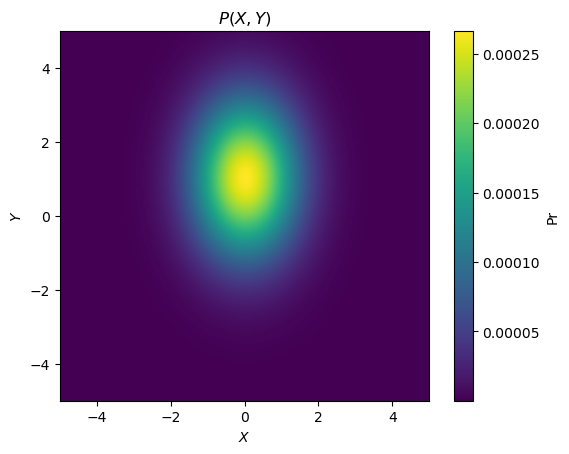

In [2]:
# Vectors containing range of values for RVs X and Y
X = np.arange(-5, 5, 0.05)
Y = np.arange(-5, 5, 0.05)

# Probability distribution parameters
muX = 0
muY = 1
sigmaX = 1
sigmaY = 1.5

# Single variable distributions
pX = np.exp(-(X - muX)**2 / (2 * sigmaX**2))
pY = np.exp(-(Y - muY)**2 / (2 * sigmaY**2))

# Take outer product of 1-D distributions to get joint distributions of X and Y
joint = np.outer(pY, pX)
joint /= np.sum(joint)  # Normalize

# Plot
fig, ax = plt.subplots()
extent = [-5, 5, -5, 5]
ci = ax.imshow(joint, origin="lower", extent=extent)
cbar = fig.colorbar(ci, ax=ax, label="Pr")
# cbar.set_ticks([])
ax.set(xlabel="$X$", ylabel="$Y$", title="$P(X, Y)$")
plt.show()

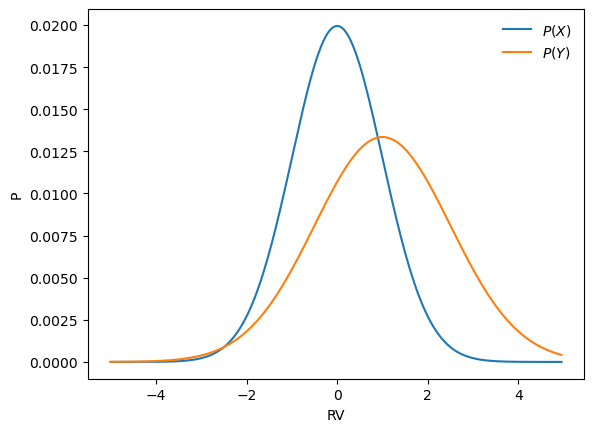

In [3]:
# Compute marginal distributions of one variable by summing over the other
X_marg = joint.sum(axis=0)
Y_marg = joint.sum(axis=1)

# Plot the marginal distributions of X and Y in same figure
fig, ax = plt.subplots()
ax.plot(X, X_marg, label="$P(X)$")
ax.plot(Y, Y_marg, label="$P(Y)$")
ax.set(xlabel="RV", ylabel="P")
ax.legend(frameon=False)
plt.show()

### Why marginalization is important

- Allows you to solve lots of problems - we frequently only care about a subset of variables
- Allows you to properly deal with "nuisance" variables
- Commonplace within Bayesian models - in reality, any model with a layer in between the world state and measurements
- Will sometimes need it to compute denominator of Bayes' Rule

---
## Plan for Wednesday class (March 19, 2025)

- Quiz on KFs and some marginalization
- Continuing on with Combining Inference and Utility
- KF problem
- Checking in on final projects!


## Statistical Decision Theory

<center><img src="images/figI-trommershauser-et-al.png" width=850></center>

- Sketch out actual task
- Other examples?
- [Trommershauser & Landy (2008)](https://canvas.ubc.ca/courses/177413/files/folder/articles?preview=43535725) provides a great intuitive overview of Statistical Decision Theory

## How can we make optimal decisions when potential rewards and costs are involved? 

- Up until now, we were mainly dealing with "pure" perceptual tasks
- We assumed the ideal observer is either trying to maximize accuracy (discrete tasks) or minimize MSE (continuous tasks), which are reasonable assumptions
- We now consider decisions that are tied to actions and that have different consequences

<center><img src="images/kording-and-wolpert-2006-box-1.png" width=700></center>

<center>From Kording & Wolpert (2006)</center>

## Decision Theory: What type of function?

- Don't be confused by all the different terminology you will see. They all refer to essentially the same thing (you can either replace one term for another or flip the sign to switch out terms)
    - Cost function
    - Loss function
    - J
    - Utility function (opposite sign as previous three)
    - Reward function (similar to utility)
- Depending on whether we are counting up "losses" or "gains", the ideal observer wants to minimize or maximize these quantities

## Simple real world example

<img src="images/fig13-1.png">

$$EC(a) = \sum_s C(a, s)p(s)$$

<center><b>Work out expected costs of each action.</b></center>

## Statistical Decision Theory 

What is the best movement plan? Agent must take into account potential rewards and costs in deciding? Agent should also take into account the uncertain mapping from movement plan (selected action) to outcome (actual reach trajectory). 

&nbsp;

<center><img src="images/figI-trommershauser-et-al.png" width=850></center>

<center><img src="images/figII-trommershauser-et-al.png" width=750></center>

<center><b>From Trommershauser et al (2008)</b></center>

## How to test optimal movement planning in the lab? 

<center><img src="images/fig1-trommershauser-et-al.png"></center>

### We'll go to whiteboard to develop the mathematical framework 

We'll end by embedding this framework into a motor control problem (see Trommershauser papers on Canvas!)




***Go to problem set to show plots.***

## For next week

- Work on your final projects
- Read Ch 13 and re-read section in Ch 8.7 on "Following the arrows"
- Work on problem 13.8 to better understand Statistical Decision Theory
- **Tutorials are now in Rm 2222**